# Real-time versus normalised-time registration

### The issue

The usual workflow (nlreg1d, and notebooks 1–2 here) linearly registers all observations to a
common grid over [0, 1] *before* nonlinear registration. That step does two things: it resamples
(harmless for smooth data), and it rescales every observation's time axis by its own duration.
The rescaling changes the first derivatives: after normalisation, dF/ds of a short (fast) trial
is inflated relative to a long (slow) trial by the ratio of their durations. Since the SRSF is
q = sign(f′)√|f′| — and derivative DTW likewise works on f′ — the elastic alignment then compares
slopes expressed in different physical time units.

`reg1d` now offers **real-time registration**: pass the observations as a list (different
lengths allowed) together with their sampling interval / frequency / time vectors, and

- the observations are never resampled before alignment;
- SRSFs are computed with derivatives in physical time;
- the dynamic programme runs between each observation's own grid and a reference grid
  (n_ref points over [0, T_ref], T_ref = mean duration by default);
- the warps Γ_i map reference time onto each observation's real time (`info['warps_realtime']`,
  in seconds); the normalised warps γ_i(s) = Γ_i(s T_ref)/T_i are stored in `result.warps` as usual;
- `info['displacement_realtime']` = Γ_i(τ) − τ T_i/T_ref is the deviation from a pure linear
  rescaling, in seconds.

This notebook compares the two workflows on the `Dorn2012` data (185–383 frames; taking 1 kHz
sampling, stance durations of 0.18–0.38 s across the four speeds — a factor of two, so the
difference in derivative scaling is large).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so that this notebook finds reg1d without installation
import numpy as np
from matplotlib import pyplot as plt
import reg1d
print('reg1d version:', reg1d.__version__)

reg1d version: 0.0.2


lengths: [365, 383, 299, 299, 232, 238, 185, 185]
durations (s): [0.365 0.383 0.299 0.299 0.232 0.238 0.185 0.185]


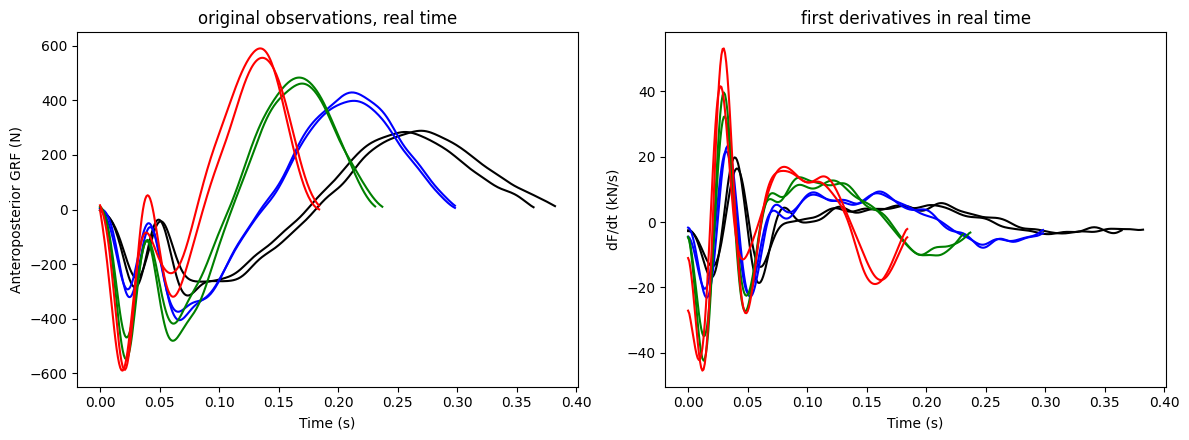

In [2]:
dataset = reg1d.data.Dorn2012()
speed   = dataset.group
ylist   = list(dataset.y)                       # ragged list: 8 observations, 185-383 frames
fs      = 1000.0                                # assumed sampling frequency (Hz)
colors  = ['k','b','g','r']
labels  = [f'Speed = {i}' for i in range(4)]
print('lengths:', [len(yy) for yy in ylist])
print('durations (s):', np.round([len(yy)/fs for yy in ylist], 3))

fig,AX = plt.subplots(1, 2, figsize=(12,4.5))
for i,yy in enumerate(ylist):
    AX[0].plot(np.arange(yy.size)/fs, yy, color=colors[speed[i]])
    AX[0].set_xlabel('Time (s)'); AX[0].set_title('original observations, real time')
    AX[1].plot(np.arange(yy.size)/fs, np.gradient(yy, 1/fs)/1000, color=colors[speed[i]])
    AX[1].set_xlabel('Time (s)'); AX[1].set_ylabel('dF/dt (kN/s)'); AX[1].set_title('first derivatives in real time')
AX[0].set_ylabel('Anteroposterior GRF (N)')
plt.tight_layout(); plt.show()

## 1. SRSF registration: normalised time versus real time

NonlinearRegistrationResult (srsf)
    y        : (8, 101)
    warps    : (8, 101)
    t        : [0, 0.27225] (101 points)
    template : (101,)
    islinear : False
    info     : ['realtime', 'durations', 'lengths', 'warps_realtime', 'displacement_realtime', 'q', 'niter', 'cost']

reference duration T_ref = 0.272 s


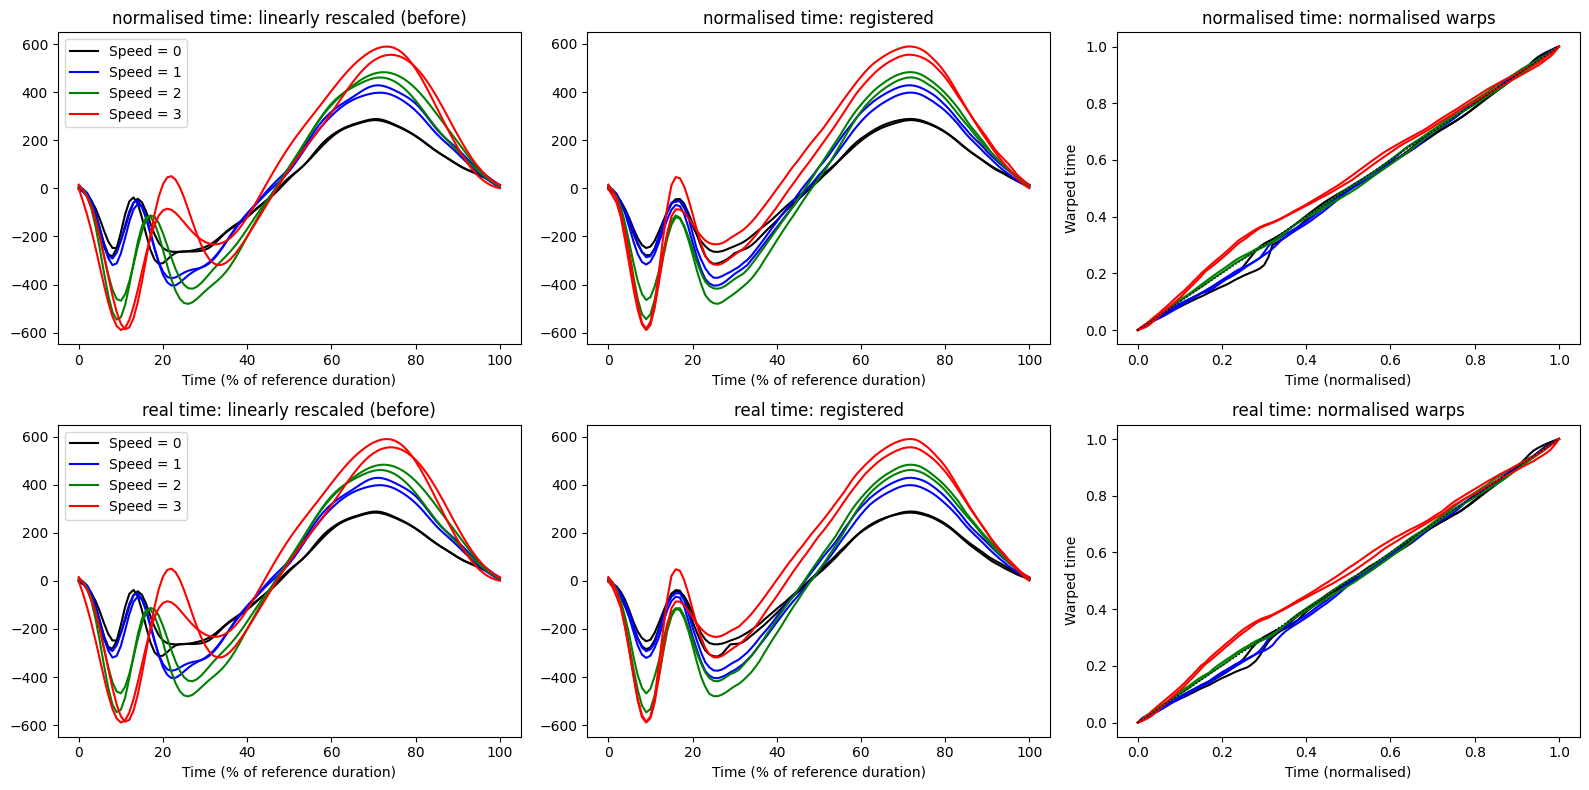

max |normalised warp difference| per observation: [0.009 0.033 0.008 0.015 0.005 0.004 0.004 0.009]
SD of propulsive-peak time (% of domain): before 1.20, normalised 0.33, real 0.00


In [3]:
yi     = reg1d.register_linear(ylist, n=101).y
r_norm = reg1d.register_srsf(yi, max_iter=5)                          # normalised-time workflow
r_real = reg1d.register_srsf(ylist, t=f'fs={fs:g}', max_iter=5)       # real-time workflow
print(r_real)
print(f'reference duration T_ref = {r_real.t[-1]:.3f} s')

fig,AX = plt.subplots(2, 3, figsize=(16,8))
for row,(r,name) in enumerate([(r_norm,'normalised time'),(r_real,'real time')]):
    reg1d.plot.plot_curves(r.y0, group=speed, ax=AX[row,0], colors=colors, x='percent', labels=labels); AX[row,0].set_title(f'{name}: linearly rescaled (before)')
    reg1d.plot.plot_curves(r.y,  group=speed, ax=AX[row,1], colors=colors, x='percent', legend=False); AX[row,1].set_title(f'{name}: registered')
    r.warps.plot(ax=AX[row,2], group=speed, colors=colors, legend=False); AX[row,2].set_title(f'{name}: normalised warps')
    for ax in AX[row,:2]: ax.set_xlabel('Time (% of reference duration)')
plt.tight_layout(); plt.show()

print('max |normalised warp difference| per observation:', np.abs(r_real.warps.asarray() - r_norm.warps.asarray()).max(axis=1).round(3))
print(f'SD of propulsive-peak time (% of domain): before {np.argmax(yi,axis=1).std():.2f}, '
      f'normalised {np.argmax(r_norm.y,axis=1).std():.2f}, real {np.argmax(r_real.y,axis=1).std():.2f}')

The two workflows give similar but not identical warps. The differences are largest for the
observations whose duration is furthest from the reference (the slowest and fastest trials): in
normalised time their SRSFs are scaled by √(T_ref/T_i) relative to real time, which changes the
relative weight of their features in the alignment cost and hence the compromise the dynamic
programme strikes between aligning the braking dips and the propulsive peak.

### Real-time warps and displacement fields

In real time, "no warping" is not the identity but the linear rescaling Γ(τ) = τ·T_i/T_ref
(the dotted lines below). The real-time displacement field is the deviation from that line, in
seconds: it says by how much a feature of observation i was moved, in physical time.

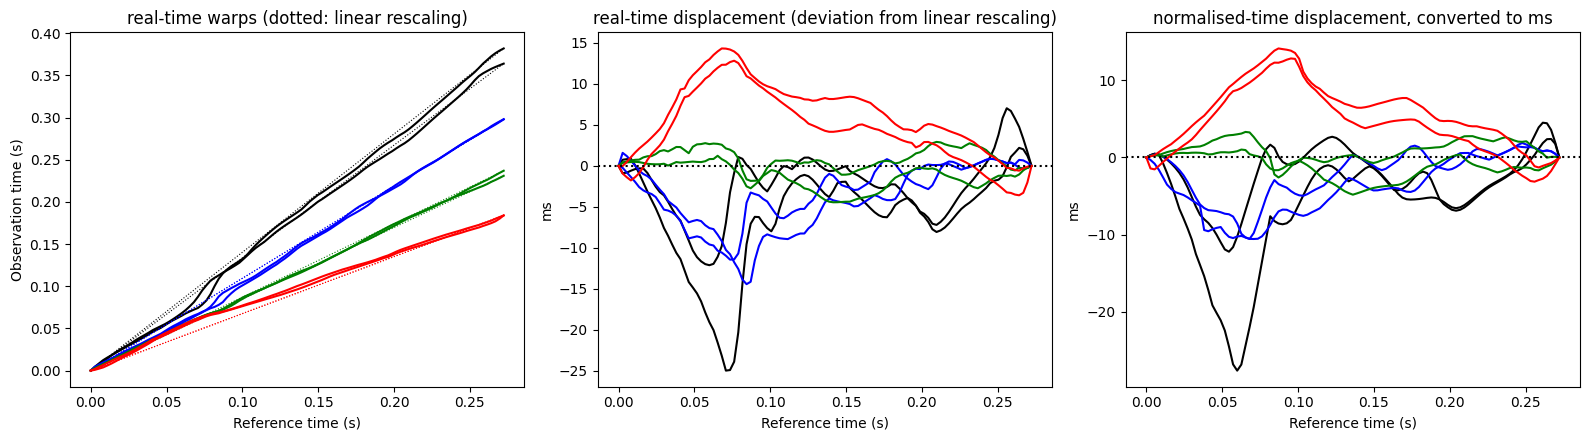

In [4]:
tau = r_real.t
fig,AX = plt.subplots(1, 3, figsize=(16,4.5))
for i in range(8):
    c = colors[speed[i]]
    AX[0].plot(tau, r_real.info['warps_realtime'][i], color=c)
    AX[0].plot([0, tau[-1]], [0, r_real.info['durations'][i]], color=c, ls=':', lw=0.8)
    AX[1].plot(tau, 1000*r_real.info['displacement_realtime'][i], color=c)
    AX[2].plot(tau, 1000*r_norm.displacement_fields[i]*r_real.info['durations'][i], color=c)
AX[0].set_xlabel('Reference time (s)'); AX[0].set_ylabel('Observation time (s)'); AX[0].set_title('real-time warps (dotted: linear rescaling)')
AX[1].axhline(0, color='k', ls=':'); AX[1].set_xlabel('Reference time (s)'); AX[1].set_ylabel('ms'); AX[1].set_title('real-time displacement (deviation from linear rescaling)')
AX[2].axhline(0, color='k', ls=':'); AX[2].set_xlabel('Reference time (s)'); AX[2].set_ylabel('ms'); AX[2].set_title('normalised-time displacement, converted to ms')
plt.tight_layout(); plt.show()

## 2. Derivative information

The right-hand panel of the first figure showed that the fastest trials have loading rates
several times those of the slowest. After normalisation this information is partly mixed with
the duration: a steep slope in normalised time may be a steep slope in real time, or a short
trial. Real-time registration keeps loading rates in physical units throughout, so the registered
derivatives (`result.apply` on the ragged list of real-time derivatives) remain comparable across
speeds.

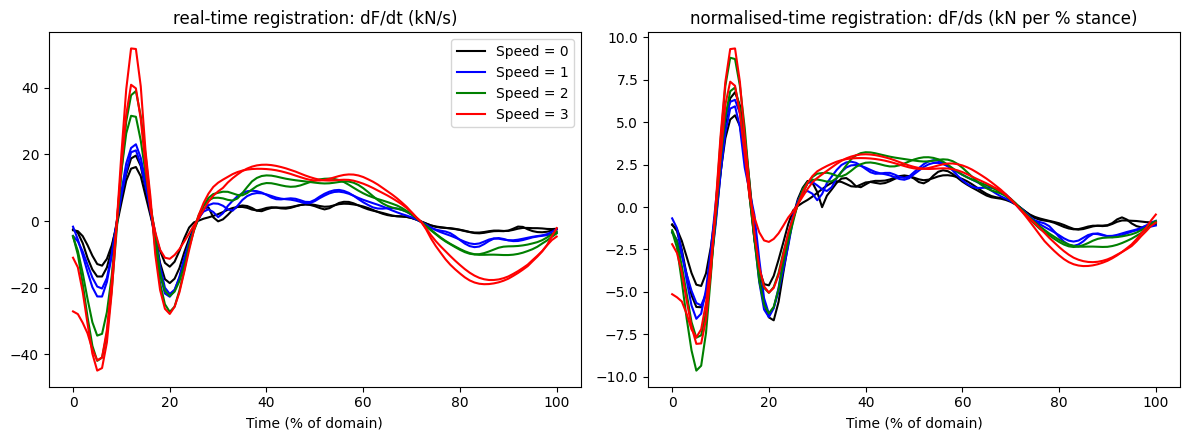

In [5]:
dydt      = [np.gradient(yy, 1/fs)/1000 for yy in ylist]          # kN/s, each on its own grid
dydt_real = r_real.apply(dydt)                                      # (8,101) on the reference axis
dydt_norm = r_norm.apply(np.gradient(yi, axis=1)*100/1000)           # normalised-time derivative per % stance, kN per % 
fig,AX = plt.subplots(1, 2, figsize=(12,4.5))
reg1d.plot.plot_curves(dydt_real, group=speed, ax=AX[0], colors=colors, x='percent', labels=labels); AX[0].set_title('real-time registration: dF/dt (kN/s)')
reg1d.plot.plot_curves(dydt_norm, group=speed, ax=AX[1], colors=colors, x='percent', legend=False); AX[1].set_title('normalised-time registration: dF/ds (kN per % stance)')
for ax in AX: ax.set_xlabel('Time (% of domain)')
plt.tight_layout(); plt.show()

## 3. Real-time DTW and landmark registration

The same ragged input works for `register_dtw` and `register_landmark`. For DTW, derivative
estimates are divided by the sampling interval so that they, too, are compared in physical
time. Note that slope-constrained step patterns (`'strict'`) cannot bridge length ratios beyond
their slope range (here up to 383/101 ≈ 3.8 against a 101-point reference); use `symmetric2`
with warp smoothing, or set `n_ref` close to the observation lengths.

landmark targets (s): [0.127 0.195]


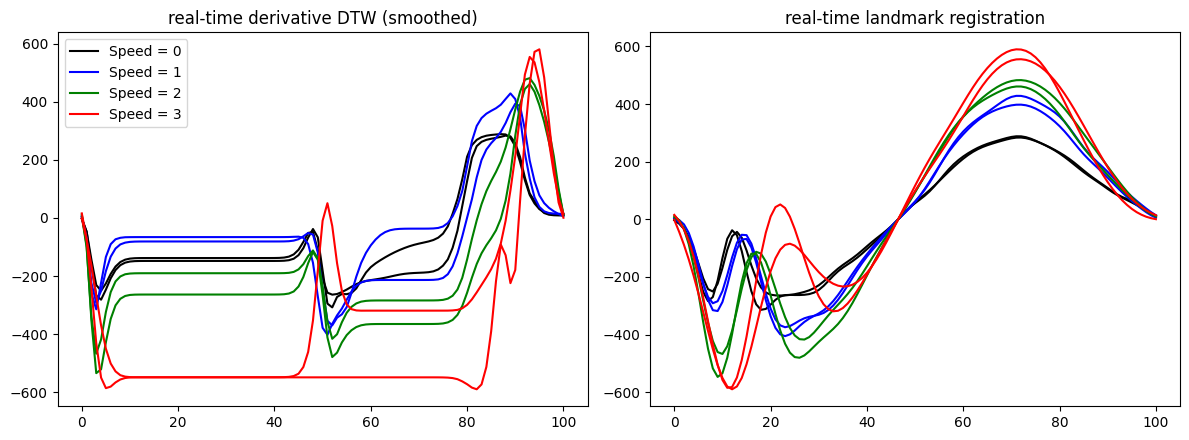

In [6]:
r_dtw = reg1d.register_dtw(ylist, t=1/fs, derivative=True, smooth=0.03)
r_lm  = reg1d.register_landmark(ylist, t=1/fs, kinds=('zero','max'))
print('landmark targets (s):', r_lm.info['targets'].round(3))
fig,AX = plt.subplots(1, 2, figsize=(12,4.5))
reg1d.plot.plot_curves(r_dtw.y, group=speed, ax=AX[0], colors=colors, x='percent', labels=labels); AX[0].set_title('real-time derivative DTW (smoothed)')
reg1d.plot.plot_curves(r_lm.y,  group=speed, ax=AX[1], colors=colors, x='percent', legend=False); AX[1].set_title('real-time landmark registration')
plt.tight_layout(); plt.show()

## 4. Which one to use?

- If the scientific time axis is **normalised** (percent stance, percent gait cycle) and
  duration is not of interest, the classical workflow is appropriate, and the SRSF's amplitude
  sensitivity to the duration rescaling is part of that model.
- If **physical time** matters — loading rates, absolute timing hypotheses, comparing conditions
  with very different durations (as here: a factor of two across speeds) — register in real time.
  The registered data still live on a common reference axis (so downstream statistics are
  unchanged), but the warps are physically interpretable (seconds onto seconds), the derivatives
  keep their units, and the displacement fields separate "this trial is shorter" (the linear
  rescaling) from "this feature occurred earlier within the trial" (the deviation from it).
- In both cases the differences between the two workflows on these data are moderate (normalised
  warp differences up to a few percent of the domain), concentrated in the trials whose duration
  is furthest from the reference; for datasets with smaller duration variation they will be
  smaller still.